In [1]:
import os
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import r2_score

In [2]:
savefig_path = os.path.join (".")
assert (Path(savefig_path).is_dir())

# Fig.3 NPLS plot for SMRT, RepoRT: unique entrees and all entrees, and HMDB

In [34]:
from rdkit.Chem import MolFromSmiles, MolFromInchi

from rdkit import RDConfig

contrib_path = os.path.join(RDConfig.RDContribDir, 'NP_Score')

sys.path.append(contrib_path)

import npscorer

fscore = npscorer.readNPModel()

from scipy.stats import gaussian_kde

import random

reading NP model ...
model in


In [35]:
path2smrt = os.path.join ("..","..", "data", "SMRT", "SMRT_data.csv")
path2report = os.path.join ("..","..", "data", "RepoRT", "raw_data", "complete_raw_data.tsv")
path2hmdb = os.path.join (".", "metabolites.csv")


In [36]:
smrt_df = pd.read_csv (path2smrt, sep = ";")
report_df = pd.read_csv (path2report, sep = "\t", dtype = {"dir_id":str})
no_smrt_df = report_df[report_df["dir_id"] != "0186"]
hmdb_df = pd.read_csv(path2hmdb)

C:\Users\leonz\AppData\Local\Temp\ipykernel_55460\1238073584.py:2: DtypeWarning: Columns (2,14,35,37,39,41,43,45,47,49,51,53,55,57,59,61,77,79,81,83,85,87,89,91,93,95,97,99,101,103,117,119,121,123,125,127,129,131,133,135,137,139,141,143,159,161,163,165,167,169,171,173,175,177,179,181,183,185,204,210,216) have mixed types. Specify dtype option on import or set low_memory=False.
  report_df = pd.read_csv (path2report, sep = "\t", dtype = {"dir_id":str})


In [37]:
smrt_inchi_array = smrt_df.loc[:, "inchi"].values
unique_entrees_array = np.unique(no_smrt_df["smiles.std"])
report_all_entrees_smiles = no_smrt_df.loc[:, "smiles.std"].values
hmdb_df.dropna(subset=["SMILES"], inplace=True)
hmdb_smiles_array = hmdb_df.sample(20000).loc[:, "SMILES"].values

In [38]:
smrt_mol_array = [ MolFromInchi (inchi) for inchi in smrt_inchi_array ]
report_all_entrees_mol_array = [ MolFromSmiles (smiles, sanitize=True) for smiles in report_all_entrees_smiles]
report_unique_entrees_mol_array = [ MolFromSmiles(smiles, sanitize=True) for smiles in unique_entrees_array]
hmdb_mol_array = [ MolFromSmiles(smiles, sanitize=True) for smiles in hmdb_smiles_array ]

[15:16:04] Explicit valence for atom # 14 N, 4, is greater than permitted
[15:16:04] ERROR: Explicit valence for atom # 14 N, 4, is greater than permitted

[15:16:04] Explicit valence for atom # 16 N, 4, is greater than permitted
[15:16:04] ERROR: Explicit valence for atom # 16 N, 4, is greater than permitted

[15:16:04] Explicit valence for atom # 16 N, 4, is greater than permitted
[15:16:04] ERROR: Explicit valence for atom # 16 N, 4, is greater than permitted

[15:16:04] Explicit valence for atom # 18 N, 4, is greater than permitted
[15:16:04] ERROR: Explicit valence for atom # 18 N, 4, is greater than permitted

[15:16:04] Explicit valence for atom # 17 N, 4, is greater than permitted
[15:16:04] ERROR: Explicit valence for atom # 17 N, 4, is greater than permitted

[15:16:04] Explicit valence for atom # 15 N, 4, is greater than permitted
[15:16:04] ERROR: Explicit valence for atom # 15 N, 4, is greater than permitted

[15:16:05] Explicit valence for atom # 16 N, 4, is greater than 

In [39]:
smrt_npls_array = [ npscorer.scoreMol (mol, fscore) for mol in smrt_mol_array if mol is not None]
all_entrees_npls_array = [ npscorer.scoreMol (mol, fscore) for mol in report_all_entrees_mol_array if mol is not None]
unique_entrees_npls_array = [ npscorer.scoreMol (mol, fscore) for mol in report_unique_entrees_mol_array if mol is not None]
hmdb_npls_array = [ npscorer.scoreMol(mol, fscore) for mol in hmdb_mol_array if mol is not None]

In [40]:
plt.rcParams["font.family"] = "Times New Roman"

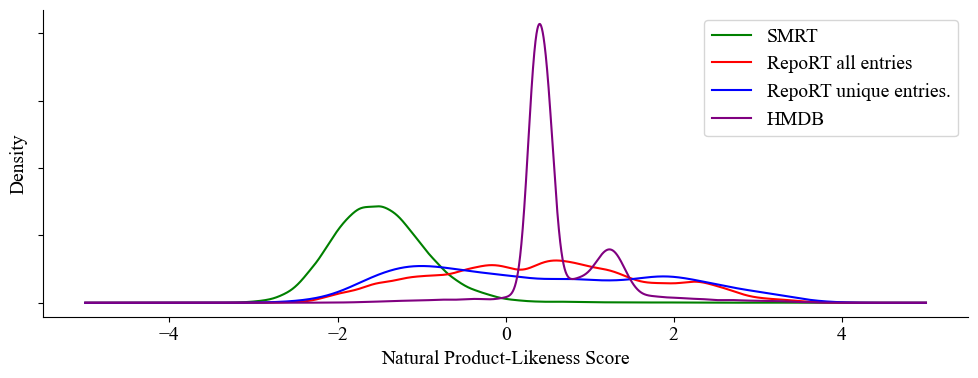

In [41]:
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(111)
smrt_kde = gaussian_kde(smrt_npls_array, bw_method='silverman')
report_all_kde = gaussian_kde(all_entrees_npls_array, bw_method='silverman')
report_unique_kde = gaussian_kde(unique_entrees_npls_array,bw_method='silverman')
hmdb_kde = gaussian_kde(hmdb_npls_array, bw_method='silverman')
x_val = np.linspace (-5, 5, 5000)
ax.plot (x_val, smrt_kde(x_val), "green", label="SMRT")
ax.plot(x_val, report_all_kde(x_val), "red", label="RepoRT all entries")
ax.plot (x_val, report_unique_kde(x_val), "blue", label="RepoRT unique entries.")
ax.plot(x_val, hmdb_kde(x_val), "purple", label="HMDB")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yticklabels([])
ax.set_xlabel("Natural Product-Likeness Score")
ax.set_ylabel("Density")
plt.legend(loc="upper right")
plt.savefig (os.path.join(savefig_path, "Fig3_NPLS_plot.png"), format="png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# Fig.4. Comparison between Baseline and Baseline scaffold

In [46]:
moldesc_type = ["RepoRT_RP", "RepoRT_moldesc"]
split_type = ["model_per_repo", "model_per_repo_scaffold"]
paths2datas = [os.path.join ("..", "..", "results4TFG", moldesc, "with_SMRT", "no_filtered", split, "01_06_2026", "Results.tsv") for split in split_type for moldesc in moldesc_type]

path2baseline = os.path.join ("..", "..", "results4TFG", "RepoRT_RP_kfold", "with_SMRT", "no_filtered", "model_per_repo", "09_06_2026", "all_results.tsv")
dfs = [ pd.read_csv(path2df, sep='\t') for path2df in paths2datas ]
path2baseline_modldesc = os.path.join ("..","..", "results4TFG", "RepoRT_RP_kfold_moldesc", "with_SMRT", "no_filtered", "model_per_repo", "09_06_2026", "all_results.tsv")

baseline_df = pd.read_csv (path2baseline, sep='\t')
baseline_moldesc_df = pd.read_csv(path2baseline_modldesc, sep='\t')
baseline_sca_df = dfs[2]
baseline_sca_moldesc_df = dfs[3]


In [47]:
baseline_pred = baseline_df.loc[:, "pred_rt"].values
baseline_true = baseline_df.loc[:, "rt"].values
baseline_smrt_pred = baseline_df[baseline_df["cc_id"] == "cc_125"].loc[:, "pred_rt"].values
baseline_smrt_true = baseline_df[baseline_df["cc_id"] == "cc_125"].loc[:, "rt"].values

baseline_moldesc_pred = baseline_moldesc_df.loc[:, "pred_rt"].values
baseline_moldesc_true = baseline_moldesc_df.loc[:,"rt"].values
baseline_moldesc_smrt_pred = baseline_moldesc_df[baseline_moldesc_df["cc_id"] == "cc_125"].loc[:,"pred_rt"].values
baseline_moldesc_smrt_true = baseline_moldesc_df[baseline_moldesc_df["cc_id"] == "cc_125"].loc[:,"rt"].values

baseline_sca_pred = baseline_sca_df.loc[:,"pred_rt"].values
baseline_sca_true = baseline_sca_df.loc[:, "rt"].values
baseline_sca_smrt_pred = baseline_sca_df[baseline_sca_df["cc_id"] == "cc_125"].loc[:,"pred_rt"].values
baseline_sca_smrt_true = baseline_sca_df[baseline_sca_df["cc_id"] == "cc_125"].loc[:,"rt"].values

baseline_sca_moldesc_pred = baseline_sca_moldesc_df.loc[:, "pred_rt"].values
baseline_sca_moldesc_true = baseline_sca_moldesc_df.loc[:, "rt"].values
baseline_sca_moldesc_smrt_pred = baseline_sca_moldesc_df[baseline_sca_moldesc_df["cc_id"] == "cc_125"].loc[:, "pred_rt"].values
baseline_sca_moldesc_smrt_true = baseline_sca_moldesc_df[baseline_sca_moldesc_df["cc_id"] == "cc_125"].loc[:, "rt"].values

In [48]:
baseline_mae = 63.84
baseline_mae_std = 2.23
baseline_rmse = 85.24
baseline_rmse_std = 2.45
baseline_rel_error = 6.55
baseline_rel_error_std = 0.16
baseline_r2 = r2_score(y_true=baseline_true, y_pred=baseline_pred)

baseline_moldesc_mae = 61.20
baseline_moldesc_mae_std = 1.27
baseline_moldesc_rmse = 81.40
baseline_moldesc_rmse_std = 1.62
baseline_moldesc_rel_error = 6.34
baseline_moldesc_rel_error_std = 0.13
baseline_moldesc_r2 = r2_score(y_true=baseline_moldesc_true, y_pred=baseline_moldesc_pred)

baseline_sca_mae = 77.57
baseline_sca_rmse = 169.18
baseline_sca_rel_error = 8.03
baseline_sca_r2 = r2_score(y_true=baseline_sca_true, y_pred=baseline_sca_pred)

baseline_sca_moldesc_mae = 72.44
baseline_sca_moldesc_rmse = 160.37
baseline_sca_moldesc_rel_error = 7.40
baseline_sca_moldesc_r2 = r2_score(y_true=baseline_sca_moldesc_true, y_pred=baseline_sca_moldesc_pred)

In [49]:
baseline_df = baseline_df[baseline_df["cc_id"]!= "cc_125"].sample(7000)
baseline_moldesc_df = baseline_moldesc_df[baseline_moldesc_df["cc_id"] != "cc_125"].sample(7000)

In [50]:
baseline_pred = baseline_df.loc[:,"pred_rt"].values
baseline_true = baseline_df.loc[:, "rt"].values

baseline_moldesc_pred = baseline_moldesc_df.loc[:,"pred_rt"].values
baseline_moldesc_true = baseline_moldesc_df.loc[:,"rt"].values

In [51]:
plt.rcParams["font.family"] = "Times New Roman"

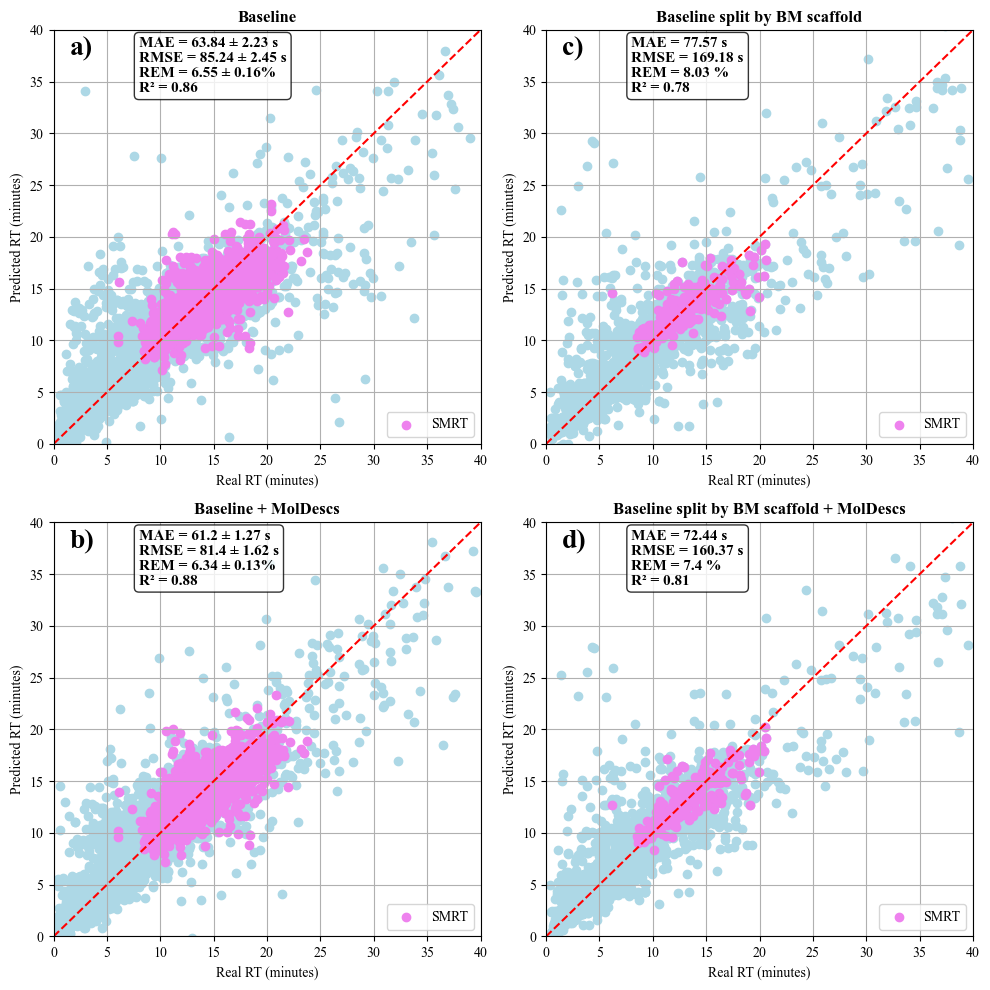

In [53]:
fig,axis = plt.subplots(2,2,figsize=(10,10))
for x,y in zip(baseline_true/60, baseline_pred/60):
    axis[0,0].scatter(x,y,color="lightblue")

for x,y in zip(baseline_smrt_true/60, baseline_smrt_pred/60):
    axis[0,0].scatter(x,y,color="violet")

axis[0,0].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[0,0].scatter([],[],color="violet", label="SMRT")

axis[0,0].text(8, 34, f"MAE = {baseline_mae:.2f} ± {baseline_mae_std:.2f} s\nRMSE = {baseline_rmse:.2f} ± {baseline_rmse_std:.2f} s\nREM = {baseline_rel_error:.2f} ± {baseline_rel_error_std:.2f}%\nR² = {baseline_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )

axis[0,0].text (1.5, 37.5, f"a)", fontsize=20, fontweight="bold", fontname="Times New Roman",)
axis[0,0].set_xlim(0, 40)
axis[0,0].set_ylim(0, 40)
axis[0,0].set_xlabel("Real RT (minutes)")
axis[0,0].set_ylabel("Predicted RT (minutes)")
axis[0,0].set_title("Baseline",fontweight="bold", fontsize=12)
axis[0,0].grid(True)
axis[0,0].legend(loc="lower right")

for x,y in zip(baseline_moldesc_true/60, baseline_moldesc_pred/60):
    axis[1,0].scatter(x,y,color="lightblue")

for x,y in zip(baseline_moldesc_smrt_true/60, baseline_moldesc_smrt_pred/60):
    axis[1,0].scatter(x,y,color="violet")

axis[1,0].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[1,0].scatter([],[],color="violet", label="SMRT")

axis[1,0].text(8, 34, f"MAE = {baseline_moldesc_mae} ± {baseline_moldesc_mae_std} s\nRMSE = {baseline_moldesc_rmse} ± {baseline_moldesc_rmse_std} s\nREM = {baseline_moldesc_rel_error} ± {baseline_moldesc_rel_error_std}%\nR² = {baseline_moldesc_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[1,0].text (1.5, 37.5, f"b)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[1,0].set_xlim(0, 40)
axis[1,0].set_ylim(0, 40)
axis[1,0].set_xlabel("Real RT (minutes)")
axis[1,0].set_ylabel("Predicted RT (minutes)")
axis[1,0].set_title("Baseline + MolDescs",fontweight="bold", fontsize=12)
axis[1,0].grid(True)
axis[1,0].legend(loc="lower right")

for x,y in zip(baseline_sca_true/60, baseline_sca_pred/60):
    axis[0,1].scatter(x,y,color="lightblue")

for x,y in zip(baseline_sca_smrt_true/60, baseline_sca_smrt_pred/60):
    axis[0,1].scatter(x,y,color="violet")

axis[0,1].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[0,1].scatter([],[],color="violet", label="SMRT")

axis[0,1].text(8, 34, f"MAE = {baseline_sca_mae} s\nRMSE = {baseline_sca_rmse} s\nREM = {baseline_sca_rel_error} %\nR² = {baseline_sca_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[0,1].text (1.5, 37.5, f"c)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[0,1].set_xlim(0, 40)
axis[0,1].set_ylim(0, 40)
axis[0,1].set_xlabel("Real RT (minutes)")
axis[0,1].set_ylabel("Predicted RT (minutes)")
axis[0,1].set_title("Baseline split by BM scaffold",fontweight="bold", fontsize=12)
axis[0,1].grid(True)
axis[0,1].legend(loc="lower right")

for x,y in zip(baseline_sca_moldesc_true/60, baseline_sca_moldesc_pred/60):
    axis[1,1].scatter(x,y,color="lightblue")

for x,y in zip(baseline_sca_moldesc_smrt_true/60, baseline_sca_moldesc_smrt_pred/60):
    axis[1,1].scatter(x,y,color="violet")

axis[1,1].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[1,1].scatter([],[],color="violet", label="SMRT")

axis[1,1].text(8, 34, f"MAE = {baseline_sca_moldesc_mae} s\nRMSE = {baseline_sca_moldesc_rmse} s\nREM = {baseline_sca_moldesc_rel_error} %\nR² = {baseline_sca_moldesc_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[1,1].text (1.5, 37.5, f"d)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[1,1].set_xlim(0, 40)
axis[1,1].set_ylim(0, 40)
axis[1,1].set_xlabel("Real RT (minutes)")
axis[1,1].set_ylabel("Predicted RT (minutes)")
axis[1,1].set_title("Baseline split by BM scaffold + MolDescs", fontweight="bold", fontsize=12)
axis[1,1].grid(True)
axis[1,1].legend(loc="lower right")
plt.tight_layout()

plt.savefig(os.path.join(savefig_path, "Fig4_Baseline_comparisons.png"), format="png", dpi=300)
plt.show()

# Fig.8 Comparison cc_split with/no SMRT +/- MolDescs

In [34]:
plt.rcParams["font.family"] = "Times New Roman"

In [35]:
moldescs_type = ["RepoRT_RP_kfold", "RepoRT_RP_kfold_moldesc"]
datasets = ["no_SMRT", "with_SMRT"]

path2files = [ os.path.join ("..","..", "results4TFG", moldesc, dataset, "no_filtered", "cc_split", "01_06_2026", "all_results.tsv")
               for moldesc in moldescs_type for dataset in datasets ]

dfs = [ pd.read_csv (path2file, sep='\t') for path2file in path2files ]

In [36]:
no_smrt_df = dfs[0]
with_smrt_df = dfs[1]
no_smrt_moldesc_df = dfs[2]
with_smrt_moldesc_df = dfs[3]
eliminated_smrt_df = with_smrt_df[with_smrt_df["cc_id"] != "cc_125"]
eliminated_smrt_moldesc_df = with_smrt_moldesc_df[with_smrt_moldesc_df["cc_id"] != "cc_125"]

In [37]:
no_smrt_pred = no_smrt_df.loc[:, "pred_rt"].values
no_smrt_true = no_smrt_df.loc[:, "rt"].values

with_smrt_pred = with_smrt_df.loc[:,"pred_rt"].values
with_smrt_true = with_smrt_df.loc[:,"rt"].values
smrt_pred = with_smrt_df[with_smrt_df["cc_id"] == "cc_125"].loc[:,"pred_rt"].values
smrt_true = with_smrt_df[with_smrt_df["cc_id"] == "cc_125"].loc[:,"rt"].values

no_smrt_moldesc_pred = no_smrt_moldesc_df.loc[:,"pred_rt"].values
no_smrt_moldesc_true = no_smrt_moldesc_df.loc[:,"rt"].values

with_smrt_moldesc_pred = with_smrt_moldesc_df.loc[:, "pred_rt"].values
with_smrt_moldesc_true = with_smrt_moldesc_df.loc[:, "rt"].values
smrt_moldesc_pred = with_smrt_moldesc_df[with_smrt_moldesc_df["cc_id"] == "cc_125"].loc[:,"pred_rt"].values
smrt_moldesc_true = with_smrt_moldesc_df[with_smrt_moldesc_df["cc_id"] == "cc_125"].loc[:,"rt"].values

eliminated_smrt_pred = eliminated_smrt_df.loc[:,"pred_rt"].values
eliminated_smrt_true = eliminated_smrt_df.loc[:,"rt"].values

eliminated_smrt_moldesc_pred = eliminated_smrt_moldesc_df.loc[:,"pred_rt"].values
eliminated_smrt_moldesc_true = eliminated_smrt_moldesc_df.loc[:,"rt"].values

In [38]:
no_smrt_mae = 99.11
no_smrt_mae_std = 42.80
no_smrt_rmse = 156.14
no_smrt_rmse_std = 78.50
no_smrt_rel_error = 13.00
no_smrt_rel_error_std = 6.41
no_smrt_r2 = r2_score(y_true=no_smrt_true, y_pred=no_smrt_pred)

with_smrt_mae = 146.82
with_smrt_mae_std = 118.63
with_smrt_rmse = 219.47
with_smrt_rmse_std = 185.12
with_smrt_rel_error = 17.93
with_smrt_rel_error_std = 10.98
with_smrt_r2 = r2_score(y_true=with_smrt_true, y_pred=with_smrt_pred)

no_smrt_moldesc_mae = 95.90
no_smrt_moldesc_mae_std = 30.16
no_smrt_moldesc_rmse = 158.85
no_smrt_moldesc_rmse_std = 62.54
no_smrt_moldesc_rel_error = 13.57
no_smrt_moldesc_rel_error_std = 8.35
no_smrt_moldesc_r2 = r2_score(y_true=no_smrt_moldesc_true, y_pred=no_smrt_moldesc_pred)

with_smrt_moldesc_mae = 126.30
with_smrt_moldesc_mae_std = 85.33
with_smrt_moldesc_rmse = 189.10
with_smrt_moldesc_rmse_std = 118.02
with_smrt_moldesc_rel_error = 15.42
with_smrt_moldesc_rel_error_std = 8.17
with_smrt_moldesc_r2 = r2_score(y_true=with_smrt_moldesc_true, y_pred=with_smrt_moldesc_pred)

eliminated_smrt_mae = 125.18
eliminated_smrt_mae_std = 96.49
eliminated_smrt_rmse = 202.43
eliminated_smrt_rmse_std = 176.12
eliminated_smrt_rel_error =16.81
eliminated_smrt_rel_error_std = 10.90
eliminated_smrt_r2 = r2_score (y_true=eliminated_smrt_true, y_pred=eliminated_smrt_pred)

eliminated_smrt_moldesc_mae = 105.41
eliminated_smrt_moldesc_mae_std = 51.23
eliminated_smrt_moldesc_rmse = 171.38
eliminated_smrt_moldesc_rmse_std = 107.33
eliminated_smrt_moldesc_rel_error =14.31
eliminated_smrt_moldesc_rel_error_std = 8.10
eliminated_smrt_moldesc_r2 = r2_score (y_true=eliminated_smrt_moldesc_true, y_pred=eliminated_smrt_moldesc_pred)


In [ ]:
no_smrt_df = no_smrt_df.sample(7000)
with_smrt_df = with_smrt_df[with_smrt_df["cc_id"] != "cc_125"].sample(7000)
no_smrt_moldesc_df = no_smrt_moldesc_df.sample(7000)
with_smrt_moldesc_df = with_smrt_moldesc_df[with_smrt_moldesc_df["cc_id"] != "cc_125"].sample(7000)

In [17]:
no_smrt_pred = no_smrt_df.loc[:, "pred_rt"].values
no_smrt_true = no_smrt_df.loc[:, "rt"].values

with_smrt_pred = with_smrt_df.loc[:,"pred_rt"].values
with_smrt_true = with_smrt_df.loc[:,"rt"].values

no_smrt_moldesc_pred = no_smrt_moldesc_df.loc[:,"pred_rt"].values
no_smrt_moldesc_true = no_smrt_moldesc_df.loc[:,"rt"].values

with_smrt_moldesc_pred = with_smrt_moldesc_df.loc[:, "pred_rt"].values
with_smrt_moldesc_true = with_smrt_moldesc_df.loc[:, "rt"].values

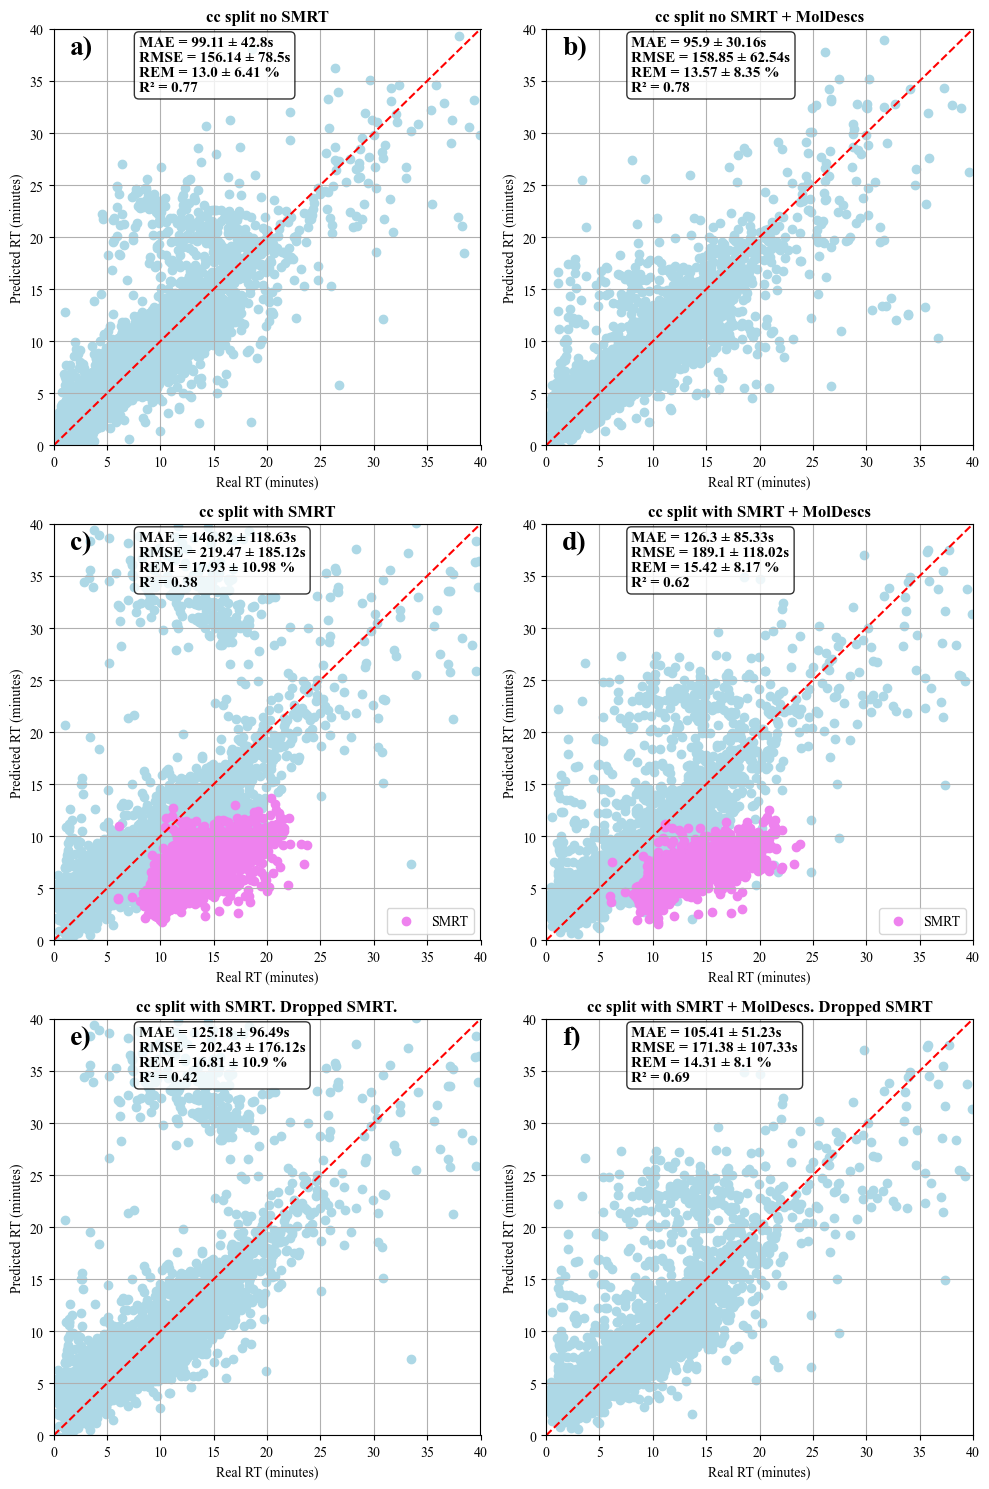

In [18]:
fig,axis = plt.subplots(3,2,figsize=(10,15))

#NO SMRT NO MOLDESCS
for x,y in zip(no_smrt_true/60 , no_smrt_pred/60):
    axis[0,0].scatter(x,y,color="lightblue")

axis[0,0].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")

axis[0,0].text(8, 34, f"MAE = {no_smrt_mae} ± {no_smrt_mae_std}s\nRMSE = {no_smrt_rmse} ± {no_smrt_rmse_std}s\nREM = {no_smrt_rel_error} ± {no_smrt_rel_error_std} %\nR² = {no_smrt_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[0,0].text (1.5, 37.5, f"a)", fontsize=20, fontweight="bold", fontname="Times New Roman",)
axis[0,0].set_xlim(0, 40)
axis[0,0].set_ylim(0, 40)
axis[0,0].set_xlabel("Real RT (minutes)")
axis[0,0].set_ylabel("Predicted RT (minutes)")
axis[0,0].set_title("cc split no SMRT",fontweight="bold", fontsize=12)
axis[0,0].grid(True)

# NO SMRT + MOLDESCS
for x,y in zip(no_smrt_moldesc_true/60, no_smrt_moldesc_pred/60):
    axis[0,1].scatter(x,y,color="lightblue")

axis[0,1].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")

axis[0,1].text(8, 34, f"MAE = {no_smrt_moldesc_mae} ± {no_smrt_moldesc_mae_std}s\nRMSE = {no_smrt_moldesc_rmse} ± {no_smrt_moldesc_rmse_std}s\nREM = {no_smrt_moldesc_rel_error} ± {no_smrt_moldesc_rel_error_std} %\nR² = {no_smrt_moldesc_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[0,1].text (1.5, 37.5, f"b)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[0,1].set_xlim(0, 40)
axis[0,1].set_ylim(0, 40)
axis[0,1].set_xlabel("Real RT (minutes)")
axis[0,1].set_ylabel("Predicted RT (minutes)")
axis[0,1].set_title("cc split no SMRT + MolDescs",fontweight="bold", fontsize=12)
axis[0,1].grid(True)

# WITH SMRT NO MOLDESCS
for x,y in zip(with_smrt_true/60, with_smrt_pred/60):
    axis[1,0].scatter(x,y,color="lightblue")
#
for x,y in zip(smrt_true/60, smrt_pred/60):
    axis[1,0].scatter(x,y,color="violet")

axis[1,0].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[1,0].scatter([],[],color="violet", label="SMRT")

axis[1,0].text(8, 34, f"MAE = {with_smrt_mae} ± {with_smrt_mae_std}s\nRMSE = {with_smrt_rmse} ± {with_smrt_rmse_std}s\nREM = {with_smrt_rel_error} ± {with_smrt_rel_error_std} %\nR² = {with_smrt_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[1,0].text (1.5, 37.5, f"c)", fontsize=20, fontweight="bold", fontname="Times New Roman",)
axis[1,0].set_xlim(0, 40)
axis[1,0].set_ylim(0, 40)
axis[1,0].set_xlabel("Real RT (minutes)")
axis[1,0].set_ylabel("Predicted RT (minutes)")
axis[1,0].set_title("cc split with SMRT",fontweight="bold", fontsize=12)
axis[1,0].grid(True)
axis[1,0].legend()

# WITH SMRT + MOLDESCS
for x,y in zip(with_smrt_moldesc_true/60, with_smrt_moldesc_pred/60):
    axis[1,1].scatter(x,y,color="lightblue")

for x,y in zip(smrt_moldesc_true/60, smrt_moldesc_pred/60):
    axis[1,1].scatter(x,y,color="violet")

axis[1,1].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[1,1].scatter([],[],color="violet", label="SMRT")

axis[1,1].text(8, 34, f"MAE = {with_smrt_moldesc_mae} ± {with_smrt_moldesc_mae_std}s\nRMSE = {with_smrt_moldesc_rmse} ± {with_smrt_moldesc_rmse_std}s\nREM = {with_smrt_moldesc_rel_error} ± {with_smrt_moldesc_rel_error_std} %\nR² = {with_smrt_moldesc_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[1,1].text (1.5, 37.5, f"d)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[1,1].set_xlim(0, 40)
axis[1,1].set_ylim(0, 40)
axis[1,1].set_xlabel("Real RT (minutes)")
axis[1,1].set_ylabel("Predicted RT (minutes)")
axis[1,1].set_title("cc split with SMRT + MolDescs",fontweight="bold", fontsize=12)
axis[1,1].grid(True)
axis[1,1].legend()
plt.tight_layout()

# WITH SMRT NO MOLDESCS. Dropped SMRT
for x,y in zip(with_smrt_true/60, with_smrt_pred/60):
    axis[2,0].scatter(x,y,color="lightblue")

axis[2,0].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[2,0].scatter([],[],color="violet", label="SMRT")

axis[2,0].text(8, 34, f"MAE = {eliminated_smrt_mae} ± {eliminated_smrt_mae_std}s\nRMSE = {eliminated_smrt_rmse} ± {eliminated_smrt_rmse_std}s\nREM = {eliminated_smrt_rel_error} ± {eliminated_smrt_rel_error_std} %\nR² = {eliminated_smrt_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[2,0].text (1.5, 37.5, f"e)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[2,0].set_xlim(0, 40)
axis[2,0].set_ylim(0, 40)
axis[2,0].set_xlabel("Real RT (minutes)")
axis[2,0].set_ylabel("Predicted RT (minutes)")
axis[2,0].set_title("cc split with SMRT. Dropped SMRT.",fontweight="bold", fontsize=12)
axis[2,0].grid(True)

# WITH SMRT + MOLDESCS. Dropped SMRT
for x,y in zip(with_smrt_moldesc_true/60, with_smrt_moldesc_pred/60):
    axis[2,1].scatter(x,y,color="lightblue")

axis[2,1].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[2,1].scatter([],[],color="violet", label="SMRT")

axis[2,1].text(8, 34, f"MAE = {eliminated_smrt_moldesc_mae} ± {eliminated_smrt_moldesc_mae_std}s\nRMSE = {eliminated_smrt_moldesc_rmse} ± {eliminated_smrt_moldesc_rmse_std}s\nREM = {eliminated_smrt_moldesc_rel_error} ± {eliminated_smrt_moldesc_rel_error_std} %\nR² = {eliminated_smrt_moldesc_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[2,1].text (1.5, 37.5, f"f)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[2,1].set_xlim(0, 40)
axis[2,1].set_ylim(0, 40)
axis[2,1].set_xlabel("Real RT (minutes)")
axis[2,1].set_ylabel("Predicted RT (minutes)")
axis[2,1].set_title("cc split with SMRT + MolDescs. Dropped SMRT",fontweight="bold", fontsize=12)
axis[2,1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(savefig_path, "Fig5_ccsplit_comparisons.png"), format="png", dpi=300)
plt.show()

# Fig.5 Comparison random_split with/no SMRT +/- MolDescs

In [19]:
plt.rcParams["font.family"] = "Times New Roman"

In [21]:
moldescs_type = ["RepoRT_RP_kfold", "RepoRT_RP_kfold_moldesc"]
datasets = ["no_SMRT", "with_SMRT"]

path2files = [ os.path.join ("..", "..", "results4TFG", moldesc, dataset, "no_filtered", "random_split", "01_06_2026", "all_results.tsv")
               for moldesc in moldescs_type for dataset in datasets ]

dfs = [ pd.read_csv (path2file, sep='\t') for path2file in path2files ]

In [22]:
no_smrt_df = dfs[0]
with_smrt_df = dfs[1]
no_smrt_moldesc_df = dfs[2]
with_smrt_moldesc_df = dfs[3]
eliminated_smrt_df = with_smrt_df[with_smrt_df["cc_id"] != "cc_125"]
eliminated_smrt_moldesc_df = with_smrt_moldesc_df[with_smrt_moldesc_df["cc_id"] != "cc_125"]

In [23]:
no_smrt_pred = no_smrt_df.loc[:, "pred_rt"].values
no_smrt_true = no_smrt_df.loc[:, "rt"].values

with_smrt_pred = with_smrt_df.loc[:,"pred_rt"].values
with_smrt_true = with_smrt_df.loc[:,"rt"].values
smrt_pred = with_smrt_df[with_smrt_df["cc_id"] == "cc_125"].loc[:,"pred_rt"].values
smrt_true = with_smrt_df[with_smrt_df["cc_id"] == "cc_125"].loc[:,"rt"].values

no_smrt_moldesc_pred = no_smrt_moldesc_df.loc[:,"pred_rt"].values
no_smrt_moldesc_true = no_smrt_moldesc_df.loc[:,"rt"].values

with_smrt_moldesc_pred = with_smrt_moldesc_df.loc[:, "pred_rt"].values
with_smrt_moldesc_true = with_smrt_moldesc_df.loc[:, "rt"].values
smrt_moldesc_pred = with_smrt_moldesc_df[with_smrt_moldesc_df["cc_id"] == "cc_125"].loc[:,"pred_rt"].values
smrt_moldesc_true = with_smrt_moldesc_df[with_smrt_moldesc_df["cc_id"] == "cc_125"].loc[:,"rt"].values

eliminated_smrt_pred = eliminated_smrt_df.loc[:,"pred_rt"].values
eliminated_smrt_true = eliminated_smrt_df.loc[:,"rt"].values

eliminated_smrt_moldesc_pred = eliminated_smrt_moldesc_df.loc[:,"pred_rt"].values
eliminated_smrt_moldesc_true = eliminated_smrt_moldesc_df.loc[:,"rt"].values

In [24]:
no_smrt_mae = 42.80
no_smrt_mae_std = 4.02
no_smrt_rmse = 81.21
no_smrt_rmse_std = 6.70
no_smrt_rel_error = 5.26
no_smrt_rel_error_std = 0.50
no_smrt_r2 = r2_score(y_true=no_smrt_true, y_pred=no_smrt_pred)

with_smrt_mae = 41.85
with_smrt_mae_std = 3.07
with_smrt_rmse = 79.58
with_smrt_rmse_std = 4.64
with_smrt_rel_error = 4.87
with_smrt_rel_error_std = 0.41
with_smrt_r2 = r2_score(y_true=with_smrt_true, y_pred=with_smrt_pred)

no_smrt_moldesc_mae = 39.03
no_smrt_moldesc_mae_std = 2.95
no_smrt_moldesc_rmse = 76.78
no_smrt_moldesc_rmse_std = 4.97
no_smrt_moldesc_rel_error = 4.77
no_smrt_moldesc_rel_error_std = 0.41
no_smrt_moldesc_r2 = r2_score(y_true=no_smrt_moldesc_true, y_pred=no_smrt_moldesc_pred)

with_smrt_moldesc_mae = 40.92
with_smrt_moldesc_mae_std = 1.92
with_smrt_moldesc_rmse = 79.19
with_smrt_moldesc_rmse_std = 3.11
with_smrt_moldesc_rel_error = 4.83
with_smrt_moldesc_rel_error_std = 0.27
with_smrt_moldesc_r2 = r2_score(y_true=with_smrt_moldesc_true, y_pred=with_smrt_moldesc_pred)

eliminated_smrt_mae = 40.40
eliminated_smrt_mae_std = 2.08
eliminated_smrt_rmse = 79.20
eliminated_smrt_rmse_std = 5.10
eliminated_smrt_rel_error = 4.90
eliminated_smrt_rel_error_std = 0.26
eliminated_smrt_r2 = r2_score (y_true=eliminated_smrt_true, y_pred=eliminated_smrt_pred)

eliminated_smrt_moldesc_mae =39.63
eliminated_smrt_moldesc_mae_std = 1.96
eliminated_smrt_moldesc_rmse = 78.89
eliminated_smrt_moldesc_rmse_std = 3.59
eliminated_smrt_moldesc_rel_error = 4.87
eliminated_smrt_moldesc_rel_error_std = 0.24
eliminated_smrt_moldesc_r2 = r2_score (y_true=eliminated_smrt_moldesc_true, y_pred=eliminated_smrt_moldesc_pred)

In [25]:
no_smrt_df = no_smrt_df.sample(7000)
with_smrt_df = with_smrt_df[with_smrt_df["cc_id"] != "cc_125"].sample(7000)
no_smrt_moldesc_df = no_smrt_moldesc_df.sample(7000)
with_smrt_moldesc_df = with_smrt_moldesc_df[with_smrt_moldesc_df["cc_id"] != "cc_125"].sample(7000)

In [26]:
no_smrt_pred = no_smrt_df.loc[:, "pred_rt"].values
no_smrt_true = no_smrt_df.loc[:, "rt"].values

with_smrt_pred = with_smrt_df.loc[:,"pred_rt"].values
with_smrt_true = with_smrt_df.loc[:,"rt"].values

no_smrt_moldesc_pred = no_smrt_moldesc_df.loc[:,"pred_rt"].values
no_smrt_moldesc_true = no_smrt_moldesc_df.loc[:,"rt"].values

with_smrt_moldesc_pred = with_smrt_moldesc_df.loc[:, "pred_rt"].values
with_smrt_moldesc_true = with_smrt_moldesc_df.loc[:, "rt"].values

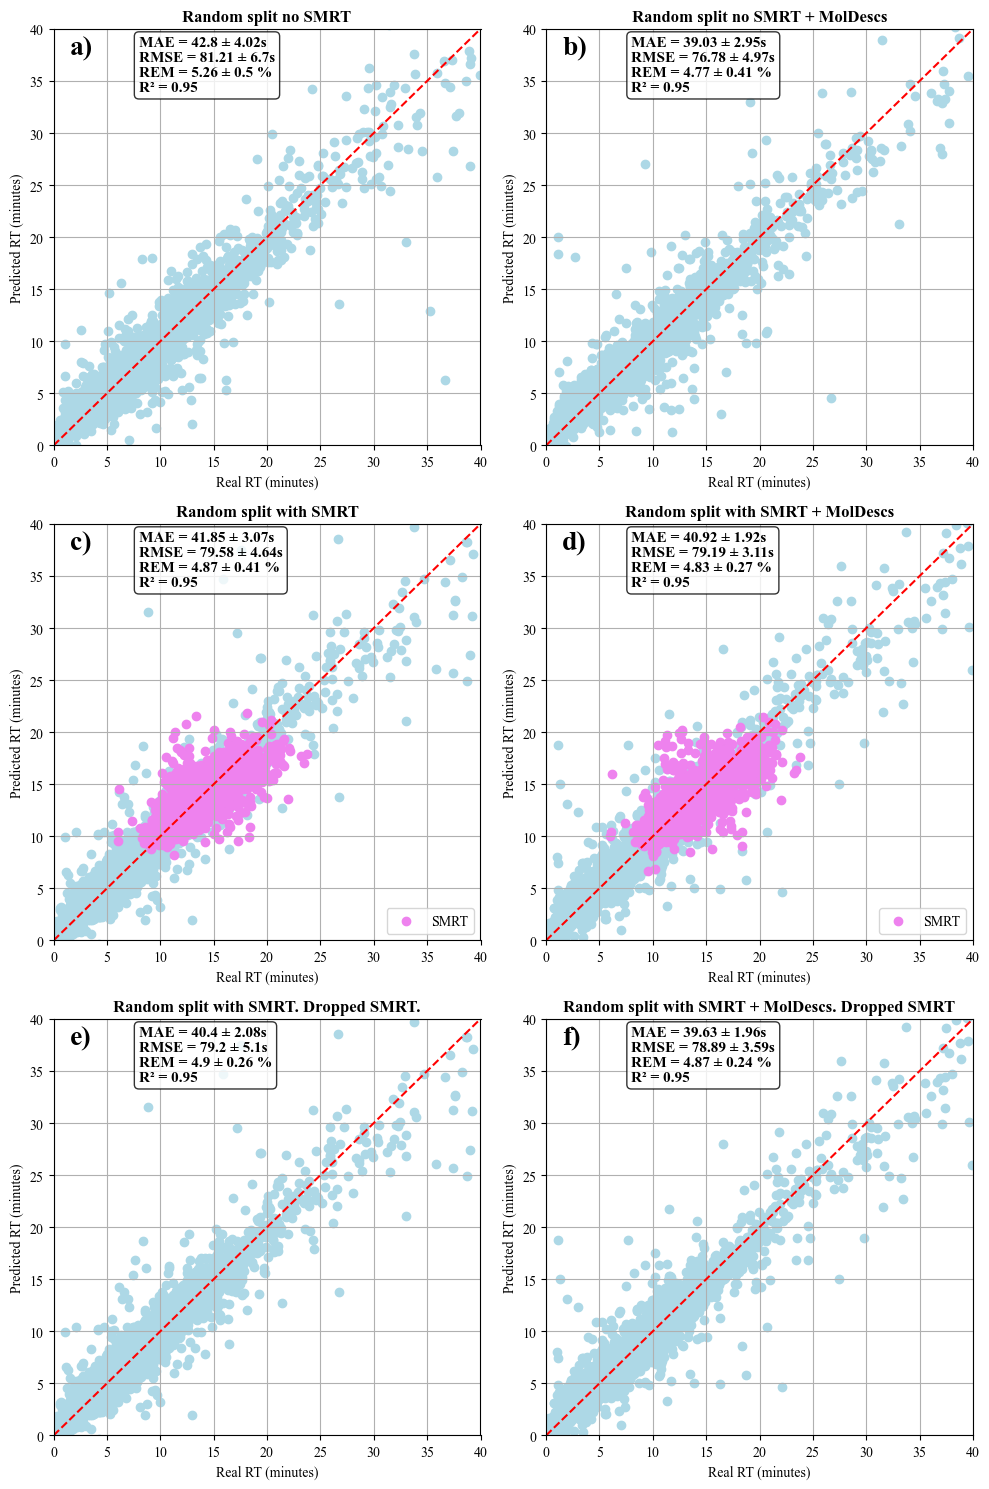

In [30]:
fig,axis = plt.subplots(3,2,figsize=(10,15))

#NO SMRT NO MOLDESCS
for x,y in zip(no_smrt_true/60 , no_smrt_pred/60):
    axis[0,0].scatter(x,y,color="lightblue")

axis[0,0].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")

axis[0,0].text(8, 34, f"MAE = {no_smrt_mae} ± {no_smrt_mae_std}s\nRMSE = {no_smrt_rmse} ± {no_smrt_rmse_std}s\nREM = {no_smrt_rel_error} ± {no_smrt_rel_error_std} %\nR² = {no_smrt_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[0,0].text (1.5, 37.5, f"a)", fontsize=20, fontweight="bold", fontname="Times New Roman",)
axis[0,0].set_xlim(0, 40)
axis[0,0].set_ylim(0, 40)
axis[0,0].set_xlabel("Real RT (minutes)")
axis[0,0].set_ylabel("Predicted RT (minutes)")
axis[0,0].set_title("Random split no SMRT",fontweight="bold", fontsize=12)
axis[0,0].grid(True)

# NO SMRT + MOLDESCS
for x,y in zip(no_smrt_moldesc_true/60, no_smrt_moldesc_pred/60):
    axis[0,1].scatter(x,y,color="lightblue")

axis[0,1].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")

axis[0,1].text(8, 34, f"MAE = {no_smrt_moldesc_mae} ± {no_smrt_moldesc_mae_std}s\nRMSE = {no_smrt_moldesc_rmse} ± {no_smrt_moldesc_rmse_std}s\nREM = {no_smrt_moldesc_rel_error} ± {no_smrt_moldesc_rel_error_std} %\nR² = {no_smrt_moldesc_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[0,1].text (1.5, 37.5, f"b)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[0,1].set_xlim(0, 40)
axis[0,1].set_ylim(0, 40)
axis[0,1].set_xlabel("Real RT (minutes)")
axis[0,1].set_ylabel("Predicted RT (minutes)")
axis[0,1].set_title("Random split no SMRT + MolDescs",fontweight="bold", fontsize=12)
axis[0,1].grid(True)

# WITH SMRT NO MOLDESCS
for x,y in zip(with_smrt_true/60, with_smrt_pred/60):
    axis[1,0].scatter(x,y,color="lightblue")

for x,y in zip(smrt_true/60, smrt_pred/60):
    axis[1,0].scatter(x,y,color="violet")

axis[1,0].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[1,0].scatter([],[],color="violet", label="SMRT")

axis[1,0].text(8, 34, f"MAE = {with_smrt_mae} ± {with_smrt_mae_std}s\nRMSE = {with_smrt_rmse} ± {with_smrt_rmse_std}s\nREM = {with_smrt_rel_error} ± {with_smrt_rel_error_std} %\nR² = {with_smrt_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[1,0].text (1.5, 37.5, f"c)", fontsize=20, fontweight="bold", fontname="Times New Roman",)
axis[1,0].set_xlim(0, 40)
axis[1,0].set_ylim(0, 40)
axis[1,0].set_xlabel("Real RT (minutes)")
axis[1,0].set_ylabel("Predicted RT (minutes)")
axis[1,0].set_title("Random split with SMRT",fontweight="bold", fontsize=12)
axis[1,0].grid(True)
axis[1,0].legend()

# WITH SMRT + MOLDESCS
for x,y in zip(with_smrt_moldesc_true/60, with_smrt_moldesc_pred/60):
    axis[1,1].scatter(x,y,color="lightblue")

for x,y in zip(smrt_moldesc_true/60, smrt_moldesc_pred/60):
    axis[1,1].scatter(x,y,color="violet")

axis[1,1].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[1,1].scatter([],[],color="violet", label="SMRT")

axis[1,1].text(8, 34, f"MAE = {with_smrt_moldesc_mae} ± {with_smrt_moldesc_mae_std}s\nRMSE = {with_smrt_moldesc_rmse} ± {with_smrt_moldesc_rmse_std}s\nREM = {with_smrt_moldesc_rel_error} ± {with_smrt_moldesc_rel_error_std} %\nR² = {with_smrt_moldesc_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[1,1].text (1.5, 37.5, f"d)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[1,1].set_xlim(0, 40)
axis[1,1].set_ylim(0, 40)
axis[1,1].set_xlabel("Real RT (minutes)")
axis[1,1].set_ylabel("Predicted RT (minutes)")
axis[1,1].set_title("Random split with SMRT + MolDescs",fontweight="bold", fontsize=12)
axis[1,1].grid(True)
axis[1,1].legend()
plt.tight_layout()

# WITH SMRT NO MOLDESCS. Dropped SMRT
for x,y in zip(with_smrt_true/60, with_smrt_pred/60):
    axis[2,0].scatter(x,y,color="lightblue")

axis[2,0].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[2,0].scatter([],[],color="violet", label="SMRT")

axis[2,0].text(8, 34, f"MAE = {eliminated_smrt_mae} ± {eliminated_smrt_mae_std}s\nRMSE = {eliminated_smrt_rmse} ± {eliminated_smrt_rmse_std}s\nREM = {eliminated_smrt_rel_error} ± {eliminated_smrt_rel_error_std} %\nR² = {eliminated_smrt_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[2,0].text (1.5, 37.5, f"e)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[2,0].set_xlim(0, 40)
axis[2,0].set_ylim(0, 40)
axis[2,0].set_xlabel("Real RT (minutes)")
axis[2,0].set_ylabel("Predicted RT (minutes)")
axis[2,0].set_title("Random split with SMRT. Dropped SMRT.",fontweight="bold", fontsize=12)
axis[2,0].grid(True)

# WITH SMRT + MOLDESCS. Dropped SMRT
for x,y in zip(with_smrt_moldesc_true/60, with_smrt_moldesc_pred/60):
    axis[2,1].scatter(x,y,color="lightblue")

axis[2,1].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[2,1].scatter([],[],color="violet", label="SMRT")

axis[2,1].text(8, 34, f"MAE = {eliminated_smrt_moldesc_mae} ± {eliminated_smrt_moldesc_mae_std}s\nRMSE = {eliminated_smrt_moldesc_rmse} ± {eliminated_smrt_moldesc_rmse_std}s\nREM = {eliminated_smrt_moldesc_rel_error} ± {eliminated_smrt_moldesc_rel_error_std} %\nR² = {eliminated_smrt_moldesc_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[2,1].text (1.5, 37.5, f"f)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[2,1].set_xlim(0, 40)
axis[2,1].set_ylim(0, 40)
axis[2,1].set_xlabel("Real RT (minutes)")
axis[2,1].set_ylabel("Predicted RT (minutes)")
axis[2,1].set_title("Random split with SMRT + MolDescs. Dropped SMRT",fontweight="bold", fontsize=12)
axis[2,1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(savefig_path, "Fig6_rdsplit_comparisons.png"), format="png", dpi=300)
plt.show()

    # Fig.6 Comparison scaffold_split with/no SMRT +/- MolDescs

In [31]:
moldescs_type = ["RepoRT_RP_kfold", "RepoRT_RP_kfold_moldesc"]
datasets = ["no_SMRT", "with_SMRT"]

path2files = [ os.path.join ("..", "..", "results4TFG", moldesc, dataset, "no_filtered", "scaffold_split", "01_06_2026", "all_results.tsv")
               for moldesc in moldescs_type for dataset in datasets ]

dfs = [ pd.read_csv (path2file, sep='\t') for path2file in path2files ]

In [32]:
no_smrt_df = dfs[0]
with_smrt_df = dfs[1]
no_smrt_moldesc_df = dfs[2]
with_smrt_moldesc_df = dfs[3]
eliminated_smrt_df = with_smrt_df[with_smrt_df["cc_id"] != "cc_125"]
eliminated_smrt_moldesc_df = with_smrt_moldesc_df[with_smrt_moldesc_df["cc_id"] != "cc_125"]

In [33]:
no_smrt_pred = no_smrt_df.loc[:, "pred_rt"].values
no_smrt_true = no_smrt_df.loc[:, "rt"].values

with_smrt_pred = with_smrt_df.loc[:,"pred_rt"].values
with_smrt_true = with_smrt_df.loc[:,"rt"].values
smrt_pred = with_smrt_df[with_smrt_df["cc_id"] == "cc_125"].loc[:,"pred_rt"].values
smrt_true = with_smrt_df[with_smrt_df["cc_id"] == "cc_125"].loc[:,"rt"].values

no_smrt_moldesc_pred = no_smrt_moldesc_df.loc[:,"pred_rt"].values
no_smrt_moldesc_true = no_smrt_moldesc_df.loc[:,"rt"].values

with_smrt_moldesc_pred = with_smrt_moldesc_df.loc[:, "pred_rt"].values
with_smrt_moldesc_true = with_smrt_moldesc_df.loc[:, "rt"].values
smrt_moldesc_pred = with_smrt_moldesc_df[with_smrt_moldesc_df["cc_id"] == "cc_125"].loc[:,"pred_rt"].values
smrt_moldesc_true = with_smrt_moldesc_df[with_smrt_moldesc_df["cc_id"] == "cc_125"].loc[:,"rt"].values

eliminated_smrt_pred = eliminated_smrt_df.loc[:,"pred_rt"].values
eliminated_smrt_true = eliminated_smrt_df.loc[:,"rt"].values

eliminated_smrt_moldesc_pred = eliminated_smrt_moldesc_df.loc[:,"pred_rt"].values
eliminated_smrt_moldesc_true = eliminated_smrt_moldesc_df.loc[:,"rt"].values

In [34]:
no_smrt_mae = 64.92
no_smrt_mae_std = 15.15
no_smrt_rmse = 120.03
no_smrt_rmse_std = 31.66
no_smrt_rel_error = 7.62
no_smrt_rel_error_std = 1.50
no_smrt_r2 = r2_score(y_true=no_smrt_true, y_pred=no_smrt_pred)

with_smrt_mae = 61.67
with_smrt_mae_std = 11.31
with_smrt_rmse = 108.86
with_smrt_rmse_std = 24.53
with_smrt_rel_error = 7.08
with_smrt_rel_error_std = 1.13
with_smrt_r2 = r2_score(y_true=with_smrt_true, y_pred=with_smrt_pred)

no_smrt_moldesc_mae = 57.14
no_smrt_moldesc_mae_std = 15.27
no_smrt_moldesc_rmse = 108.70
no_smrt_moldesc_rmse_std = 38.09
no_smrt_moldesc_rel_error = 6.73
no_smrt_moldesc_rel_error_std = 1.17
no_smrt_moldesc_r2 = r2_score(y_true=no_smrt_moldesc_true, y_pred=no_smrt_moldesc_pred)

with_smrt_moldesc_mae = 54.79
with_smrt_moldesc_mae_std = 8.22
with_smrt_moldesc_rmse = 101.23
with_smrt_moldesc_rmse_std = 19.22
with_smrt_moldesc_rel_error = 6.25
with_smrt_moldesc_rel_error_std = 0.80
with_smrt_moldesc_r2 = r2_score(y_true=with_smrt_moldesc_true, y_pred=with_smrt_moldesc_pred)

eliminated_smrt_mae = 61.31
eliminated_smrt_mae_std = 9.90
eliminated_smrt_rmse = 111.42
eliminated_smrt_rmse_std = 21.13
eliminated_smrt_rel_error =7.27
eliminated_smrt_rel_error_std = 0.71
eliminated_smrt_r2 = r2_score (y_true=eliminated_smrt_true, y_pred=eliminated_smrt_pred)

eliminated_smrt_moldesc_mae = 54.34
eliminated_smrt_moldesc_mae_std = 9.66
eliminated_smrt_moldesc_rmse = 102.97
eliminated_smrt_moldesc_rmse_std = 19.10
eliminated_smrt_moldesc_rel_error =6.42
eliminated_smrt_moldesc_rel_error_std = 0.84
eliminated_smrt_moldesc_r2 = r2_score (y_true=eliminated_smrt_moldesc_true, y_pred=eliminated_smrt_moldesc_pred)


In [35]:
no_smrt_df = no_smrt_df.sample(7000)
with_smrt_df = with_smrt_df[with_smrt_df["cc_id"] != "cc_125"].sample(7000)
no_smrt_moldesc_df = no_smrt_moldesc_df.sample(7000)
with_smrt_moldesc_df = with_smrt_moldesc_df[with_smrt_moldesc_df["cc_id"] != "cc_125"].sample(7000)

In [36]:
no_smrt_pred = no_smrt_df.loc[:, "pred_rt"].values
no_smrt_true = no_smrt_df.loc[:, "rt"].values

with_smrt_pred = with_smrt_df.loc[:,"pred_rt"].values
with_smrt_true = with_smrt_df.loc[:,"rt"].values

no_smrt_moldesc_pred = no_smrt_moldesc_df.loc[:,"pred_rt"].values
no_smrt_moldesc_true = no_smrt_moldesc_df.loc[:,"rt"].values

with_smrt_moldesc_pred = with_smrt_moldesc_df.loc[:, "pred_rt"].values
with_smrt_moldesc_true = with_smrt_moldesc_df.loc[:, "rt"].values

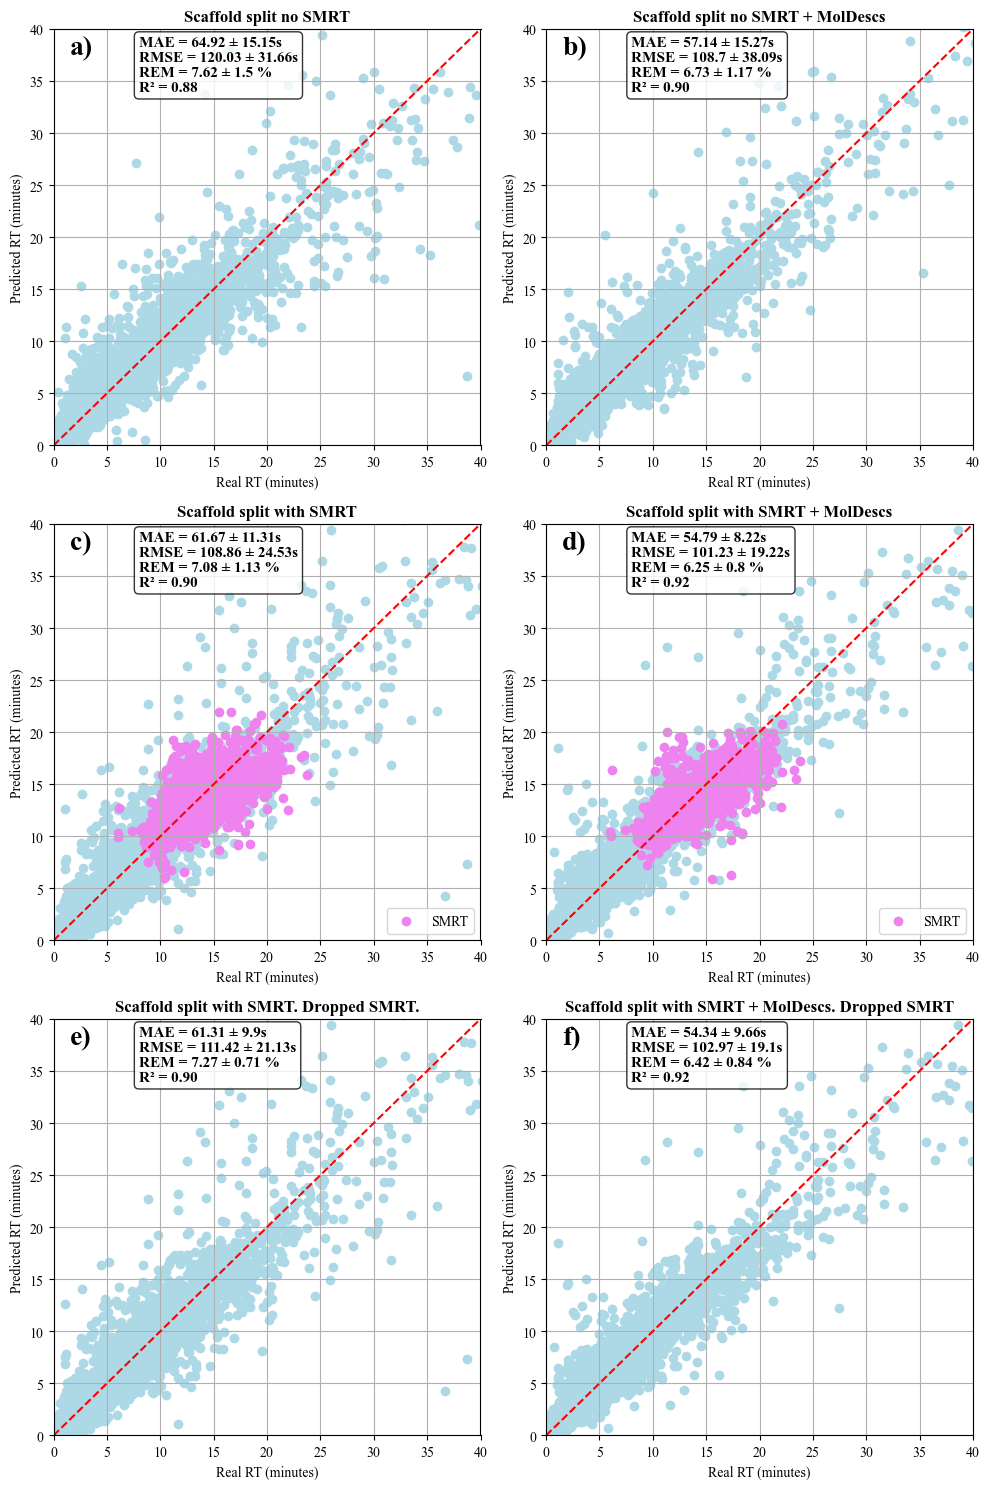

In [38]:
fig,axis = plt.subplots(3,2,figsize=(10,15))

#NO SMRT NO MOLDESCS
for x,y in zip(no_smrt_true/60 , no_smrt_pred/60):
    axis[0,0].scatter(x,y,color="lightblue")

axis[0,0].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")

axis[0,0].text(8, 34, f"MAE = {no_smrt_mae} ± {no_smrt_mae_std}s\nRMSE = {no_smrt_rmse} ± {no_smrt_rmse_std}s\nREM = {no_smrt_rel_error} ± {no_smrt_rel_error_std} %\nR² = {no_smrt_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[0,0].text (1.5, 37.5, f"a)", fontsize=20, fontweight="bold", fontname="Times New Roman",)
axis[0,0].set_xlim(0, 40)
axis[0,0].set_ylim(0, 40)
axis[0,0].set_xlabel("Real RT (minutes)")
axis[0,0].set_ylabel("Predicted RT (minutes)")
axis[0,0].set_title("Scaffold split no SMRT",fontweight="bold", fontsize=12)
axis[0,0].grid(True)

# NO SMRT + MOLDESCS
for x,y in zip(no_smrt_moldesc_true/60, no_smrt_moldesc_pred/60):
    axis[0,1].scatter(x,y,color="lightblue")

axis[0,1].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")

axis[0,1].text(8, 34, f"MAE = {no_smrt_moldesc_mae} ± {no_smrt_moldesc_mae_std}s\nRMSE = {no_smrt_moldesc_rmse} ± {no_smrt_moldesc_rmse_std}s\nREM = {no_smrt_moldesc_rel_error} ± {no_smrt_moldesc_rel_error_std} %\nR² = {no_smrt_moldesc_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[0,1].text (1.5, 37.5, f"b)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[0,1].set_xlim(0, 40)
axis[0,1].set_ylim(0, 40)
axis[0,1].set_xlabel("Real RT (minutes)")
axis[0,1].set_ylabel("Predicted RT (minutes)")
axis[0,1].set_title("Scaffold split no SMRT + MolDescs",fontweight="bold", fontsize=12)
axis[0,1].grid(True)

# WITH SMRT NO MOLDESCS
for x,y in zip(with_smrt_true/60, with_smrt_pred/60):
    axis[1,0].scatter(x,y,color="lightblue")

for x,y in zip(smrt_true/60, smrt_pred/60):
    axis[1,0].scatter(x,y,color="violet")

axis[1,0].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[1,0].scatter([],[],color="violet", label="SMRT")

axis[1,0].text(8, 34, f"MAE = {with_smrt_mae} ± {with_smrt_mae_std}s\nRMSE = {with_smrt_rmse} ± {with_smrt_rmse_std}s\nREM = {with_smrt_rel_error} ± {with_smrt_rel_error_std} %\nR² = {with_smrt_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[1,0].text (1.5, 37.5, f"c)", fontsize=20, fontweight="bold", fontname="Times New Roman",)
axis[1,0].set_xlim(0, 40)
axis[1,0].set_ylim(0, 40)
axis[1,0].set_xlabel("Real RT (minutes)")
axis[1,0].set_ylabel("Predicted RT (minutes)")
axis[1,0].set_title("Scaffold split with SMRT",fontweight="bold", fontsize=12)
axis[1,0].grid(True)
axis[1,0].legend()

# WITH SMRT + MOLDESCS
for x,y in zip(with_smrt_moldesc_true/60, with_smrt_moldesc_pred/60):
    axis[1,1].scatter(x,y,color="lightblue")

for x,y in zip(smrt_moldesc_true/60, smrt_moldesc_pred/60):
    axis[1,1].scatter(x,y,color="violet")

axis[1,1].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[1,1].scatter([],[],color="violet", label="SMRT")

axis[1,1].text(8, 34, f"MAE = {with_smrt_moldesc_mae} ± {with_smrt_moldesc_mae_std}s\nRMSE = {with_smrt_moldesc_rmse} ± {with_smrt_moldesc_rmse_std}s\nREM = {with_smrt_moldesc_rel_error} ± {with_smrt_moldesc_rel_error_std} %\nR² = {with_smrt_moldesc_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[1,1].text (1.5, 37.5, f"d)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[1,1].set_xlim(0, 40)
axis[1,1].set_ylim(0, 40)
axis[1,1].set_xlabel("Real RT (minutes)")
axis[1,1].set_ylabel("Predicted RT (minutes)")
axis[1,1].set_title("Scaffold split with SMRT + MolDescs",fontweight="bold", fontsize=12)
axis[1,1].grid(True)
axis[1,1].legend()
plt.tight_layout()

# WITH SMRT NO MOLDESCS. Dropped SMRT
for x,y in zip(with_smrt_true/60, with_smrt_pred/60):
    axis[2,0].scatter(x,y,color="lightblue")

axis[2,0].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[2,0].scatter([],[],color="violet", label="SMRT")

axis[2,0].text(8, 34, f"MAE = {eliminated_smrt_mae} ± {eliminated_smrt_mae_std}s\nRMSE = {eliminated_smrt_rmse} ± {eliminated_smrt_rmse_std}s\nREM = {eliminated_smrt_rel_error} ± {eliminated_smrt_rel_error_std} %\nR² = {eliminated_smrt_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[2,0].text (1.5, 37.5, f"e)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[2,0].set_xlim(0, 40)
axis[2,0].set_ylim(0, 40)
axis[2,0].set_xlabel("Real RT (minutes)")
axis[2,0].set_ylabel("Predicted RT (minutes)")
axis[2,0].set_title("Scaffold split with SMRT. Dropped SMRT.",fontweight="bold", fontsize=12)
axis[2,0].grid(True)

# WITH SMRT + MOLDESCS. Dropped SMRT
for x,y in zip(with_smrt_moldesc_true/60, with_smrt_moldesc_pred/60):
    axis[2,1].scatter(x,y,color="lightblue")

axis[2,1].plot(np.linspace(0,41,3000), np.linspace(0, 41, 3000), "--", color="red")
axis[2,1].scatter([],[],color="violet", label="SMRT")

axis[2,1].text(8, 34, f"MAE = {eliminated_smrt_moldesc_mae} ± {eliminated_smrt_moldesc_mae_std}s\nRMSE = {eliminated_smrt_moldesc_rmse} ± {eliminated_smrt_moldesc_rmse_std}s\nREM = {eliminated_smrt_moldesc_rel_error} ± {eliminated_smrt_moldesc_rel_error_std} %\nR² = {eliminated_smrt_moldesc_r2:.2f}",
        bbox=dict(boxstyle="round",facecolor="white", edgecolor="black", alpha=0.8),
        fontsize=11,
        fontname="Times New Roman",
        fontweight="bold"
        )
axis[2,1].text (1.5, 37.5, f"f)", fontsize=20, fontweight="bold", fontname="Times New Roman",)

axis[2,1].set_xlim(0, 40)
axis[2,1].set_ylim(0, 40)
axis[2,1].set_xlabel("Real RT (minutes)")
axis[2,1].set_ylabel("Predicted RT (minutes)")
axis[2,1].set_title("Scaffold split with SMRT + MolDescs. Dropped SMRT",fontweight="bold", fontsize=12)
axis[2,1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(savefig_path, "Fig7_mssplit_comparisons.png"), format="png", dpi=300)
plt.show()

# Fig.9. Global comparison MAE different models

In [54]:
baseline_mae = 63.84
baseline_mae_std = 2.23
baseline_moldesc_mae = 61.20
baseline_moldesc_mae_std = 1.27
baseline_sca_mae = 77.57
baseline_sca_mae_std = 0.0
baseline_sca_moldesc_mae = 72.44
baseline_sca_moldesc_mae_std = 0.0

cc_split_mae = 99.11
cc_split_mae_std = 42.8
cc_split_moldesc_mae = 95.9
cc_split_moldesc_mae_std = 30.16
cc_split_smrt_mae = 146.82
cc_split_smrt_mae_std = 118.63
cc_split_smrt_moldesc_mae = 126.30
cc_split_smrt_moldesc_mae_std = 85.33
cc_split_dropped_mae = 125.18
cc_split_dropped_mae_std = 96.49
cc_split_dropped_moldesc_mae = 105.41
cc_split_dropped_moldesc_mae_std = 51.23

rd_split_mae = 42.8
rd_split_mae_std = 4.02
rd_split_moldesc_mae = 39.02
rd_split_moldesc_mae_std = 2.95
rd_split_smrt_mae = 41.85
rd_split_smrt_mae_std = 3.07
rd_split_smrt_moldesc_mae = 40.92
rd_split_smrt_moldesc_mae_std = 1.92
rd_split_dropped_mae = 40.40
rd_split_dropped_mae_std = 2.08
rd_split_dropped_moldesc_mae = 39.63
rd_split_dropped_moldesc_mae_std = 1.96

ms_split_mae = 64.92
ms_split_mae_std = 15.15
ms_split_moldesc_mae = 57.14
ms_split_moldesc_mae_std = 15.27
ms_split_smrt_mae = 61.67
ms_split_smrt_mae_std = 11.31
ms_split_smrt_moldesc_mae = 54.79
ms_split_smrt_moldesc_mae_std = 8.22
ms_split_dropped_mae = 61.3
ms_split_dropped_mae_std = 9.90
ms_split_dropped_moldesc_mae = 54.34
ms_split_dropped_moldesc_mae_std = 9.66

In [55]:
names = [
    "Baseline",
    "Baseline + MolDescs",
    "Baseline split by MS",
    "Baseline split by MS + MolDescs",

    "cc split no SMRT",
    "cc split no SMRT + MolDescs",
    "cc split with SMRT",
    "cc split with SMRT + MolDescs",
    "cc split with SMRT. Dropped SMRT",
    "cc split with SMRT + MolDescs. Dropped SMRT",

    "Random split no SMRT",
    "Random split no SMRT + MolDescs",
    "Random split with SMRT",
    "Random split with SMRT + MolDescs",
    "Random split with SMRT. Dropped SMRT",
    "Random split with SMRT + MolDescs. Dropped SMRT",

    "Scaffold split no SMRT",
    "Scaffold split no SMRT + MolDescs",
    "Scaffold split with SMRT",
    "Scaffold split with SMRT + MolDescs",
    "Scaffold split with SMRT. Dropped SMRT",
    "Scaffold split with SMRT + MolDescs. Dropped SMRT",
]

In [56]:
maes = [
    baseline_mae,
    baseline_moldesc_mae,
    baseline_sca_mae,
    baseline_sca_moldesc_mae,

    cc_split_mae,
    cc_split_moldesc_mae,
    cc_split_smrt_mae,
    cc_split_smrt_moldesc_mae,
    cc_split_dropped_mae,
    cc_split_dropped_moldesc_mae,

    rd_split_mae,
    rd_split_moldesc_mae,
    rd_split_smrt_mae,
    rd_split_smrt_moldesc_mae,
    rd_split_dropped_mae,
    rd_split_dropped_moldesc_mae,

    ms_split_mae,
    ms_split_moldesc_mae,
    ms_split_smrt_mae,
    ms_split_smrt_moldesc_mae,
    ms_split_dropped_mae,
    ms_split_dropped_moldesc_mae,
]

In [57]:
mae_stds = [
    baseline_mae_std,
    baseline_moldesc_mae_std,
    baseline_sca_mae_std,
    baseline_sca_moldesc_mae_std,

    cc_split_mae_std,
    cc_split_moldesc_mae_std,
    cc_split_smrt_mae_std,
    cc_split_smrt_moldesc_mae_std,
    cc_split_dropped_mae_std,
    cc_split_dropped_moldesc_mae_std,

    rd_split_mae_std,
    rd_split_moldesc_mae_std,
    rd_split_smrt_mae_std,
    rd_split_smrt_moldesc_mae_std,
    rd_split_dropped_mae_std,
    rd_split_dropped_moldesc_mae_std,

    ms_split_mae_std,
    ms_split_moldesc_mae_std,
    ms_split_smrt_mae_std,
    ms_split_smrt_moldesc_mae_std,
    ms_split_dropped_mae_std,
    ms_split_dropped_moldesc_mae_std,
]

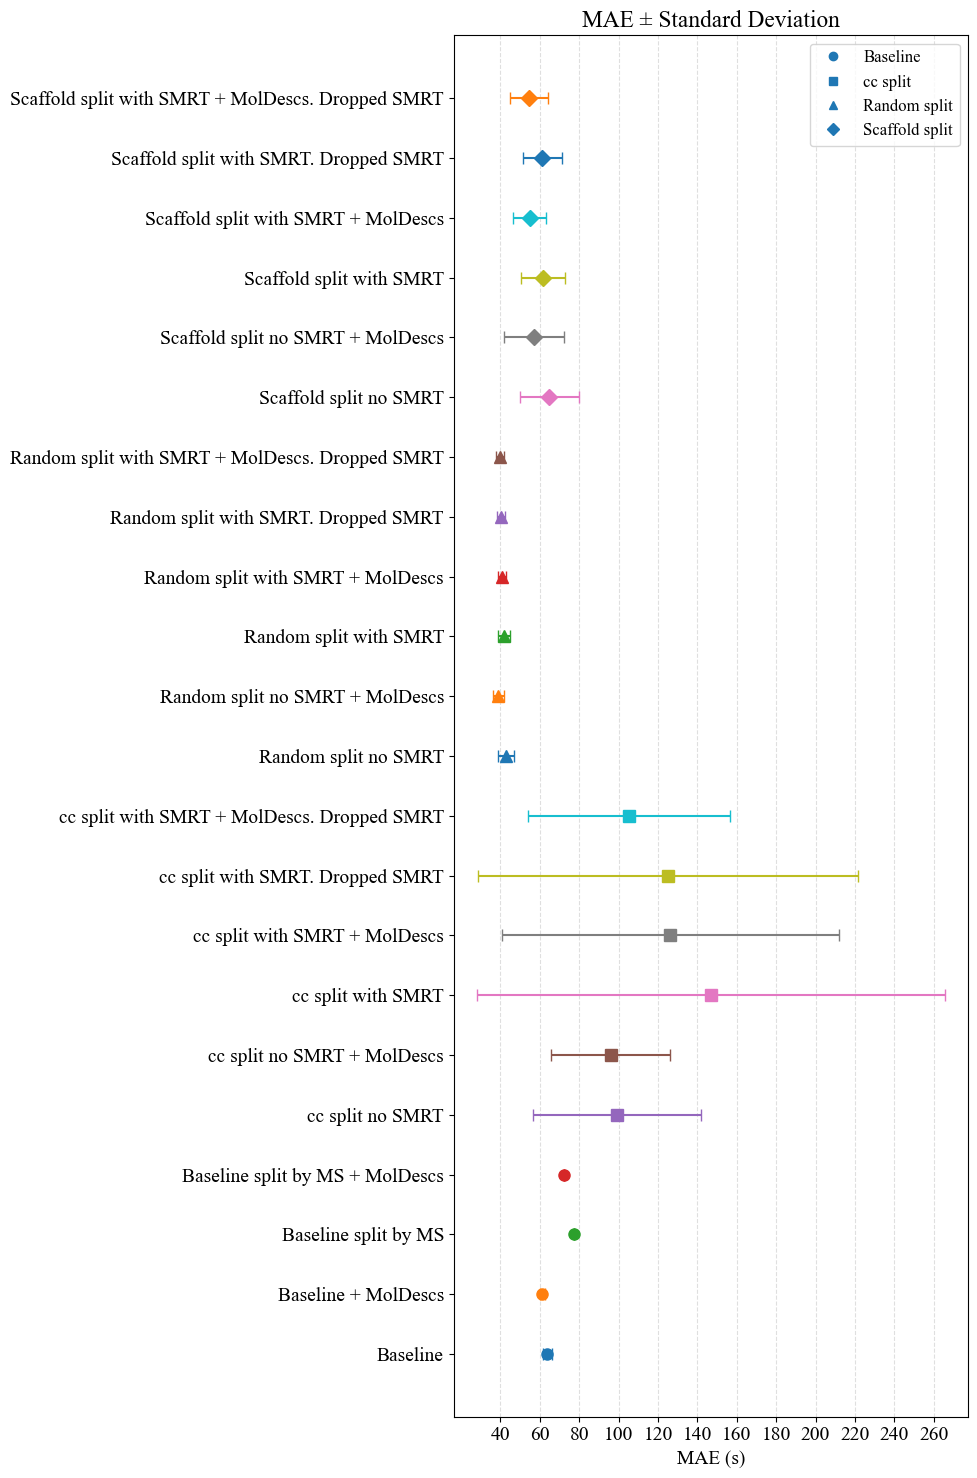

In [58]:
import matplotlib.pyplot as plt
import os

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14

# Marker by split type
markers = (
    ['o'] * 4 +   # Baseline
    ['s'] * 6 +   # CC split
    ['^'] * 6 +   # Random split
    ['D'] * 6     # Scaffold split
)

fig, ax = plt.subplots(figsize=(10, 15))

for i, (name, mae, std, marker) in enumerate(
    zip(names, maes, mae_stds, markers)
):
    ax.errorbar(
        mae,          # x-value
        i,            # y-position
        xerr=std,     # horizontal error bar
        fmt=marker,
        capsize=4,
        markersize=8,
        linestyle='none',
    )

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=14)

ax.set_xticks(range(40, 261, 20))

ax.set_xlabel("MAE (s)")
ax.set_title("MAE ± Standard Deviation")

ax.grid(axis='x', linestyle='--', alpha=0.4)

baseline_handle = plt.Line2D([], [], marker='o', linestyle='None',
                             label='Baseline')
cc_handle = plt.Line2D([], [], marker='s', linestyle='None',
                       label='cc split')
random_handle = plt.Line2D([], [], marker='^', linestyle='None',
                           label='Random split')
scaffold_handle = plt.Line2D([], [], marker='D', linestyle='None',
                             label='Scaffold split')

ax.legend(
    handles=[
        baseline_handle,
        cc_handle,
        random_handle,
        scaffold_handle
    ],
    fontsize=12,
)

plt.tight_layout()
plt.savefig(
    os.path.join(savefig_path, "Fig8_total_comparison_horizontal.png"),
    format='png',
    dpi=300
)
plt.show()